### What this notebook does

| Item | Description |
|---|---|
| Input | `screening_results.pkl` — per-condition, per-seed feature lists |
| | `labeled_splits.pkl` / `kmeans_labeled_splits.pkl` — fixed seed-42 threshold labels |
| | `threshold_log.pkl` / `kmeans_threshold_log.pkl` — thresholds for all 10 label seeds |
| Models | RF, XGBoost, SVC, Logistic Regression (ElasticNet), KNN — 5 algorithms |
| Tuning | GridSearchCV, cv = 5, scoring = f1_macro |
| Iterations (main) | 4 conditions × 10 train seeds × 5 models |
| Iterations (sensitivity) | Best condition × 10 label seeds × 10 train seeds |
| Evaluation | Test set (validation set handled separately in `validation.ipynb`) |

### Four Conditions

| Condition | Labeling | Feature Selection |
|---|---|---|
| 1 | Optuna | Fold-change Top 10 |
| 2 | Optuna | VIP ≥ 1.0 |
| 3 | K-means | Fold-change Top 10 |
| 4 | K-means | VIP ≥ 1.0 |

### Figures

| Target | Content |
|---|---|
| **Main figure** | Seed-42 representative — best model per condition: confusion matrix + ROC |
| **Supplementary** | All 10 seeds — best model per-seed confusion matrix + ROC |
| **Sensitivity** | 10 label seeds × 10 train seeds — F1 boxplot |

Pipeline order: `preprocessing` → `labeling` → `screening` → **`classification`** → `validation`

---

## Algorithm Selection Rationale

> Note for Methods section

| Algorithm | Rationale |
|---|---|
| **Random Forest** | Tree-based ensemble; robust to high feature collinearity common in microbiome data; no scaling required; provides feature importance. |
| **XGBoost** | Gradient boosting; handles class imbalance (Early / Intermediate / Late) well; generally achieves top performance on tabular data. |
| **SVC (RBF kernel)** | Effective in high-dimensional, small-sample settings; nonlinear decision boundary; class_weight='balanced' corrects for class imbalance. |
| **Logistic Regression (ElasticNet)** | Interpretable linear baseline; L1 + L2 combined regularization provides implicit feature selection in high-dimensional space. |
| **KNN** | Non-parametric baseline; no distributional assumptions; distance-based structure useful for verifying cluster geometry. |

SVC and Logistic Regression include StandardScaler within the pipeline. RF, XGBoost, and KNN do not require feature scaling.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# ── 경로 설정 ──────────────────────────────────────────────
CODE_DIR  = "/home/admin-01/taeho/BRL_chicken/revision/code"
DATA_DIR  = "/home/admin-01/taeho/BRL_chicken/revision/code/data"
PKL_DIR   = f"{DATA_DIR}/pkl"
CONF_DIR  = f"{DATA_DIR}/class_confusion"
ROC_DIR   = f"{DATA_DIR}/class_roc"
SHAP_DIR  = f"{DATA_DIR}/class_shap"

for d in [PKL_DIR, CONF_DIR, ROC_DIR, SHAP_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 상수 ───────────────────────────────────────────────────
SEEDS      = [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
LABEL_SEED = 42

C_EARLY  = '#1f77b4'
C_INTER  = '#ff7f0e'
C_LATE   = '#9467bd'


LABEL_NAMES = {0: 'Early', 1: 'Late', 2: 'Intermediate'}
LABEL_ORDER = [0, 2, 1]   # Early → Intermediate → Late
COND_LABELS = {
    'cond1': 'Optuna × FC Top10',
    'cond2': 'Optuna × VIP≥1.0',
    'cond3': 'K-means × FC Top10',
    'cond4': 'K-means × VIP≥1.0',
}
MODEL_SHORT = {
    'RandomForest':      'RF',
    'XGBoost':           'XGB',
    'SVC':               'SVC',
    'LogisticRegression':'LR',
    'KNN':               'KNN',
}

## 1. Data Load

- `screening_results.pkl` — per-condition, per-seed feature lists
- `labeled_splits.pkl` — Optuna-based labels; threshold derived from seed-42 and applied uniformly across 10 train seeds
- `kmeans_labeled_splits.pkl` — K-means-based labels; same fixed-threshold approach across 10 train seeds
- `threshold_log.pkl` — Optuna thresholds independently fit for all 10 label seeds (used in Section 13 sensitivity analysis)
- `kmeans_threshold_log.pkl` — K-means thresholds independently fit for all 10 label seeds (used in Section 13 sensitivity analysis)

In [2]:
with open(f"{PKL_DIR}/screening_results.pkl", "rb") as f:
    screen = pickle.load(f)
with open(f"{PKL_DIR}/labeled_splits.pkl", "rb") as f:
    optuna_data = pickle.load(f)
with open(f"{PKL_DIR}/kmeans_labeled_splits.pkl", "rb") as f:
    kmeans_data = pickle.load(f)
with open(f"{PKL_DIR}/threshold_log.pkl", "rb") as f:
    optuna_thr_log = pickle.load(f)
with open(f"{PKL_DIR}/kmeans_threshold_log.pkl", "rb") as f:
    kmeans_thr_log = pickle.load(f)

optuna_splits = optuna_data['labeled_splits']
kmeans_splits = kmeans_data['labeled_splits']

COND_MAP = {
    'cond1': (optuna_splits, 'cond1_optuna_fc10'),
    'cond2': (optuna_splits, 'cond2_optuna_vip'),
    'cond3': (kmeans_splits, 'cond3_kmeans_fc10'),
    'cond4': (kmeans_splits, 'cond4_kmeans_vip'),
}

print("screening_results keys:", list(screen.keys()))
print(f"threshold_log seeds: {list(optuna_thr_log.keys())}")
for cond, (_, fkey) in COND_MAP.items():
    feats_42 = screen[fkey]['per_seed_features'][LABEL_SEED]
    print(f"  {COND_LABELS[cond]}: seed-42 features = {len(feats_42)}")

screening_results keys: ['seeds', 'label_seed', 'feature_cols', 'cond1_optuna_fc10', 'cond2_optuna_vip', 'cond3_kmeans_fc10', 'cond4_kmeans_vip']
threshold_log seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  Optuna × FC Top10: seed-42 features = 10
  Optuna × VIP≥1.0: seed-42 features = 23
  K-means × FC Top10: seed-42 features = 10
  K-means × VIP≥1.0: seed-42 features = 30


## 2. Model Definitions

GridSearchCV cv=5, scoring=f1_macro.  
SVC / LR → StandardScaler  include Pipeline.

In [3]:
model_configs = {
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth":    [3, 5, 7],
            "min_samples_split": [2, 5],
        },
    },
    "XGBoost": {
        "estimator": XGBClassifier(random_state=42, eval_metric='mlogloss',
                                   verbosity=0, use_label_encoder=False),
        "params": {
            "n_estimators":  [100, 200],
            "max_depth":     [3, 5, 7],
            "learning_rate": [0.05, 0.1],
        },
    },
    "SVC": {
        "estimator": Pipeline([('sc', StandardScaler()),
                               ('svc', SVC(probability=True, class_weight='balanced'))]),
        "params": {
            "svc__C":      [0.5, 1, 2],
            "svc__gamma":  ["scale", "auto"],
            "svc__kernel": ["rbf"],
        },
    },
    "LogisticRegression": {
        "estimator": Pipeline([('sc', StandardScaler()),
                               ('lr', LogisticRegression(penalty='elasticnet', solver='saga',
                                                         max_iter=500, class_weight='balanced',
                                                         random_state=42))]),
        "params": {
            "lr__l1_ratio": [0.2, 0.5, 0.8],
            "lr__C":        [0.5, 1, 2],
        },
    },
    "KNN": {
        "estimator": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights":     ["uniform", "distance"],
        },
    },
}

## 3. Training Loop

4 conditions × 10 seeds × 5 models.  
Each seed's training set used for GridSearchCV (cv = 5); final evaluation performed on the held-out test set.  
Validation set is handled separately in `validation.ipynb`.

In [4]:
results = {c: {m: {} for m in model_configs} for c in COND_MAP}

for cond, (splits, fkey) in COND_MAP.items():
    feat_dict = screen[fkey]['per_seed_features']
    print(f"\n{'='*60}")
    print(f"Condition: {COND_LABELS[cond]}")
    print('='*60)

    for seed in SEEDS:
        feats    = feat_dict[seed]
        train_df = splits[seed]['train']
        test_df  = splits[seed]['test']
        X_train  = train_df[feats].values
        y_train  = train_df['Label'].values
        X_test   = test_df[feats].values
        y_test   = test_df['Label'].values

        for model_name, cfg in model_configs.items():
            import sklearn.base as _base
            est  = _base.clone(cfg['estimator'])
            grid = GridSearchCV(est, cfg['params'], cv=5,
                                scoring='f1_macro', n_jobs=-1, refit=True)
            grid.fit(X_train, y_train)
            best = grid.best_estimator_

            y_pred_tr = best.predict(X_train)
            y_pred_te = best.predict(X_test)

            results[cond][model_name][seed] = {
                'test_acc':    accuracy_score(y_test,  y_pred_te),
                'test_f1':     f1_score(y_test,  y_pred_te, average='macro'),
                'train_acc':   accuracy_score(y_train, y_pred_tr),
                'train_f1':    f1_score(y_train, y_pred_tr, average='macro'),
                'best_model':  best,
                'best_params': grid.best_params_,
                'features':    feats,
                'n_features':  len(feats),
            }

        print(f"  seed={seed} | " +
              " | ".join(f"{MODEL_SHORT[m]}(acc={results[cond][m][seed]['test_acc']:.2f}"
                         f" f1={results[cond][m][seed]['test_f1']:.2f})"
                         for m in model_configs))

print("\n학습 완료.")


Condition: Optuna × FC Top10


  seed=38 | RF(acc=0.87 f1=0.87) | XGB(acc=0.83 f1=0.81) | SVC(acc=0.87 f1=0.87) | LR(acc=0.85 f1=0.83) | KNN(acc=0.85 f1=0.84)
  seed=39 | RF(acc=0.83 f1=0.80) | XGB(acc=0.78 f1=0.69) | SVC(acc=0.87 f1=0.88) | LR(acc=0.85 f1=0.85) | KNN(acc=0.91 f1=0.91)
  seed=40 | RF(acc=0.89 f1=0.90) | XGB(acc=0.81 f1=0.84) | SVC(acc=0.87 f1=0.88) | LR(acc=0.83 f1=0.83) | KNN(acc=0.81 f1=0.84)
  seed=41 | RF(acc=0.85 f1=0.84) | XGB(acc=0.83 f1=0.83) | SVC(acc=0.87 f1=0.86) | LR(acc=0.91 f1=0.89) | KNN(acc=0.81 f1=0.79)
  seed=42 | RF(acc=0.85 f1=0.87) | XGB(acc=0.76 f1=0.74) | SVC(acc=0.81 f1=0.80) | LR(acc=0.74 f1=0.72) | KNN(acc=0.85 f1=0.85)
  seed=43 | RF(acc=0.81 f1=0.77) | XGB(acc=0.81 f1=0.75) | SVC(acc=0.81 f1=0.77) | LR(acc=0.81 f1=0.75) | KNN(acc=0.78 f1=0.73)
  seed=44 | RF(acc=0.89 f1=0.89) | XGB(acc=0.87 f1=0.86) | SVC(acc=0.76 f1=0.73) | LR(acc=0.70 f1=0.68) | KNN(acc=0.93 f1=0.93)
  seed=45 | RF(acc=0.81 f1=0.81) | XGB(acc=0.78 f1=0.78) | SVC(acc=0.81 f1=0.81) | LR(acc=0.78 f1=0.78) 

## 4. Results Summary

mean ± SD (test set, seed = 42)

In [5]:
rows = []
for cond in COND_MAP:
    for model_name in model_configs:
        taccs = [results[cond][model_name][s]['train_acc'] for s in SEEDS]
        accs  = [results[cond][model_name][s]['test_acc']  for s in SEEDS]
        tf1s  = [results[cond][model_name][s]['train_f1']  for s in SEEDS]
        f1s   = [results[cond][model_name][s]['test_f1']   for s in SEEDS]
        rows.append({
            'cond':        cond,
            'model_name':  model_name,
            'Condition':   COND_LABELS[cond],
            'Model':       model_name,
            'Test_Acc_Mean':  np.mean(accs),
            'Test_Acc_Std':   np.std(accs),
            'Test_F1_Mean':   np.mean(f1s),
            'Test_F1_Std':    np.std(f1s),
        })

df_rank = pd.DataFrame(rows)

top5_acc = df_rank.nlargest(5, 'Test_Acc_Mean').reset_index(drop=True)
top5_f1  = df_rank.nlargest(5, 'Test_F1_Mean').reset_index(drop=True)

print("=== Top 5 by Test Accuracy ===")
print(top5_acc[['Condition','Model','Test_Acc_Mean','Test_Acc_Std',
                'Test_F1_Mean','Test_F1_Std']].to_string(index=True))
print()
print("=== Top 5 by Test F1-macro ===")
print(top5_f1[['Condition','Model','Test_Acc_Mean','Test_Acc_Std',
               'Test_F1_Mean','Test_F1_Std']].to_string(index=True))

=== Top 5 by Test Accuracy ===
           Condition         Model  Test_Acc_Mean  Test_Acc_Std  Test_F1_Mean  Test_F1_Std
0  Optuna × FC Top10  RandomForest       0.857407      0.027530      0.847586     0.041914
1   Optuna × VIP≥1.0           SVC       0.855556      0.055432      0.845958     0.060035
2   Optuna × VIP≥1.0  RandomForest       0.850000      0.042593      0.833308     0.055932
3  Optuna × FC Top10           SVC       0.846296      0.040614      0.836235     0.052775
4  Optuna × FC Top10           KNN       0.844444      0.044752      0.839415     0.055370

=== Top 5 by Test F1-macro ===
           Condition         Model  Test_Acc_Mean  Test_Acc_Std  Test_F1_Mean  Test_F1_Std
0  Optuna × FC Top10  RandomForest       0.857407      0.027530      0.847586     0.041914
1   Optuna × VIP≥1.0           SVC       0.855556      0.055432      0.845958     0.060035
2  Optuna × FC Top10           KNN       0.844444      0.044752      0.839415     0.055370
3  Optuna × FC Top10       

## 5. Best Model Selection

Best model selected per condition based on mean test F1 score across 10 seeds.  
The seed-42 model object is used for SHAP analysis.

In [6]:
best_per_cond = {}

for cond in COND_MAP:
    best_name, best_f1 = None, -1
    for model_name in model_configs:
        f1s = [results[cond][model_name][s]['test_f1'] for s in SEEDS]
        if np.mean(f1s) > best_f1:
            best_f1  = np.mean(f1s)
            best_name = model_name
    best_per_cond[cond] = {
        'model_name': best_name,
        'mean_f1':    best_f1,
        'model_42':   results[cond][best_name][LABEL_SEED]['best_model'],
        'feats_42':   results[cond][best_name][LABEL_SEED]['features'],
    }
    print(f"{COND_LABELS[cond]:35s} → best: {best_name:20s}  F1={best_f1:.3f}")

Optuna × FC Top10                   → best: RandomForest          F1=0.848
Optuna × VIP≥1.0                    → best: SVC                   F1=0.846
K-means × FC Top10                  → best: RandomForest          F1=0.726
K-means × VIP≥1.0                   → best: SVC                   F1=0.758


## 6. Confusion Matrix — Top 5 (Main)

- Top 5 model–condition combinations by test Accuracy and F1; visualized on the seed-42 test set
- Title displays 10-seed mean ± SD Accuracy and F1
- Rows = true labels, columns = predicted labels (label order: Early → Intermediate → Late)

> Per-seed supplementary figures (all 10 seeds) → Section 12

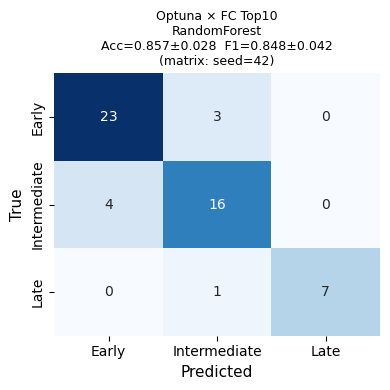

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5acc_cond1_RF_confusion.png


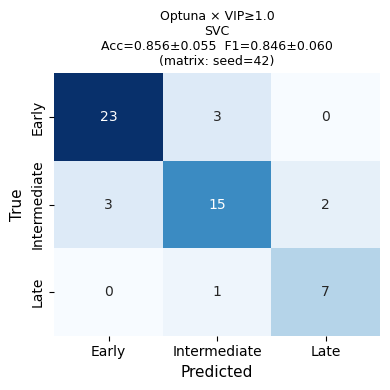

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5acc_cond2_SVC_confusion.png


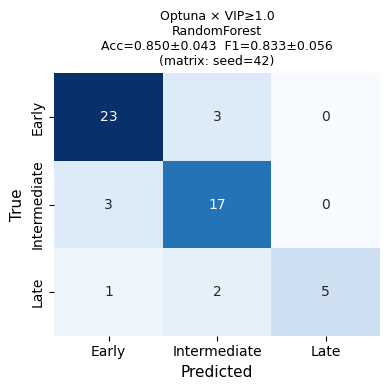

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5acc_cond2_RF_confusion.png


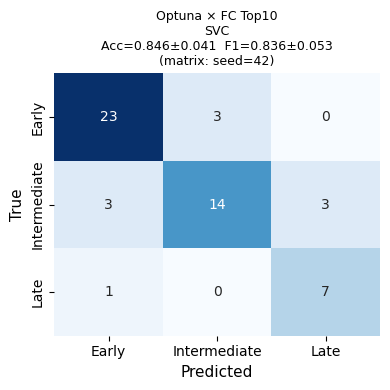

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5acc_cond1_SVC_confusion.png


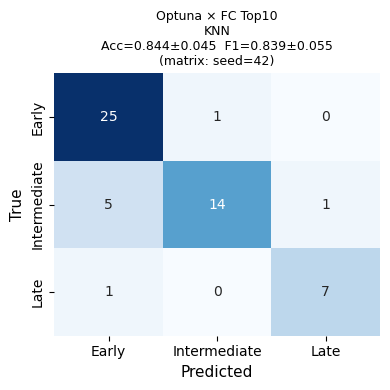

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5acc_cond1_KNN_confusion.png


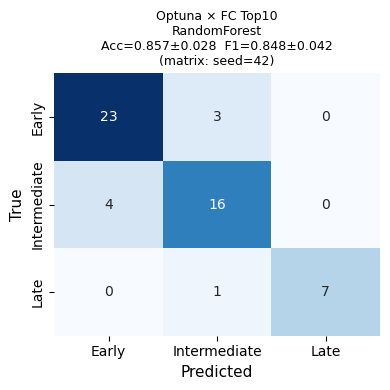

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5f1_cond1_RF_confusion.png


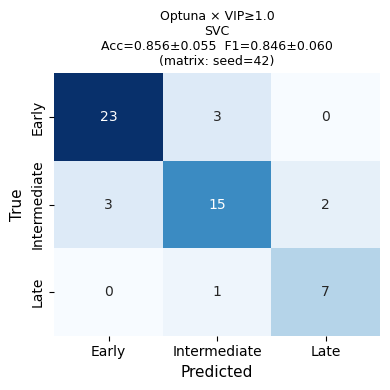

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5f1_cond2_SVC_confusion.png


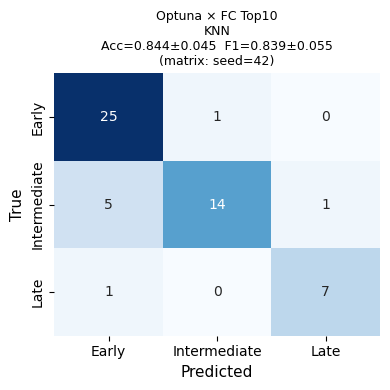

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5f1_cond1_KNN_confusion.png


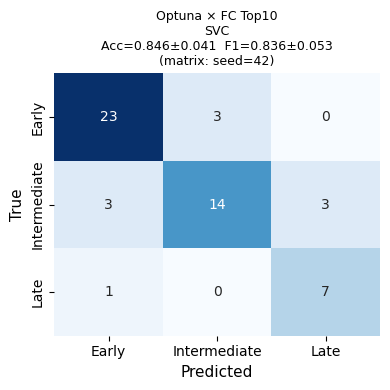

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5f1_cond1_SVC_confusion.png


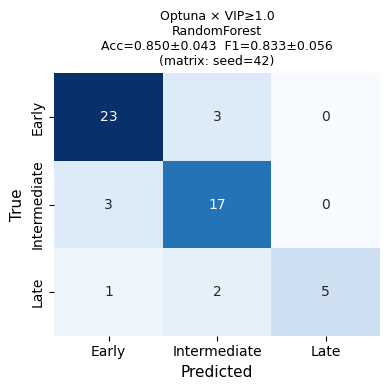

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/top5f1_cond2_RF_confusion.png


In [7]:
def plot_confusion_single(top5_df, metric_label, prefix):
    for _, row in top5_df.iterrows():
        cond = row['cond']
        mn   = row['model_name']
        sp   = COND_MAP[cond][0]

        # confusion matrix: seed=42 시각화용
        model = results[cond][mn][LABEL_SEED]['best_model']
        feats = results[cond][mn][LABEL_SEED]['features']
        te    = sp[LABEL_SEED]['test']
        X_te  = te[feats].values
        y_te  = te['Label'].values
        y_pr  = model.predict(X_te)
        cm    = confusion_matrix(y_te, y_pr, labels=LABEL_ORDER)

        # Acc / F1: 10-seed mean ± std (Excel과 동일 기준)
        accs = [results[cond][mn][s]['test_acc'] for s in SEEDS]
        f1s  = [results[cond][mn][s]['test_f1']  for s in SEEDS]
        mean_acc, std_acc = np.mean(accs), np.std(accs)
        mean_f1,  std_f1  = np.mean(f1s),  np.std(f1s)

        fig, ax = plt.subplots(figsize=(4, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=[LABEL_NAMES[l] for l in LABEL_ORDER],
                    yticklabels=[LABEL_NAMES[l] for l in LABEL_ORDER])
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.set_title(
            f"{row['Condition']}\n{mn}\n"
            f"Acc={mean_acc:.3f}±{std_acc:.3f}  F1={mean_f1:.3f}±{std_f1:.3f}\n"
            f"(matrix: seed={LABEL_SEED})",
            fontsize=9
        )
        fig.tight_layout()

        fname = f"{prefix}_{cond}_{MODEL_SHORT[mn]}_confusion.png"
        fig.savefig(f"{CONF_DIR}/{fname}", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {CONF_DIR}/{fname}")

plot_confusion_single(top5_acc, 'Test Accuracy', 'top5acc')
plot_confusion_single(top5_f1,  'Test F1-macro', 'top5f1')

## 7. ROC Curve (One-vs-Rest) — Top 5 (Main)

- Top 5 model–condition combinations by test Accuracy and F1
- ROC curves plotted on the seed-42 test set
- AUC reported in legend as 10-seed mean ± SD

> Per-seed supplementary figures (all 10 seeds) → Section 12

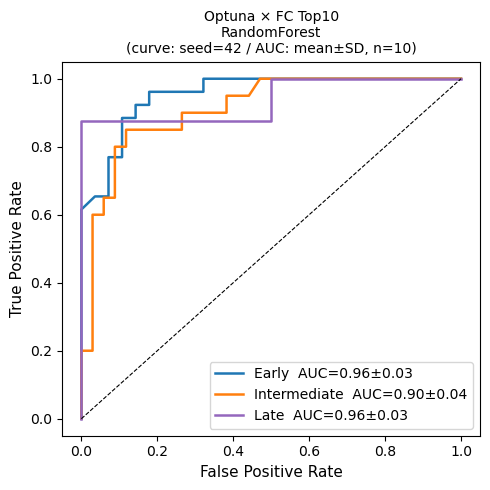

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5acc_cond1_RF_roc.png


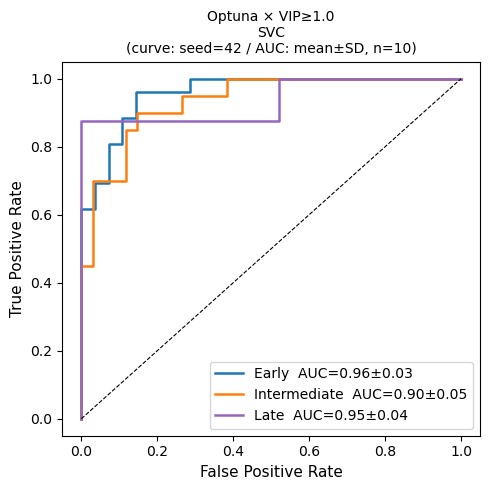

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5acc_cond2_SVC_roc.png


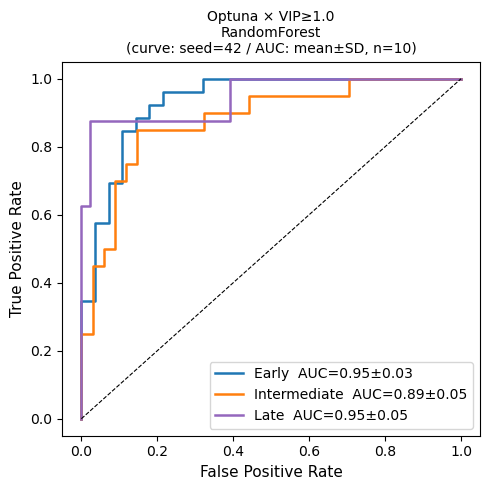

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5acc_cond2_RF_roc.png


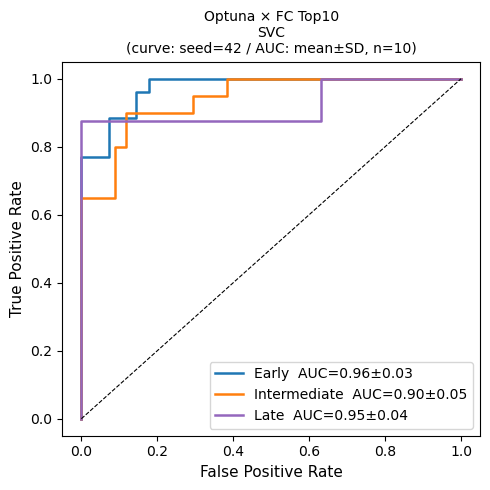

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5acc_cond1_SVC_roc.png


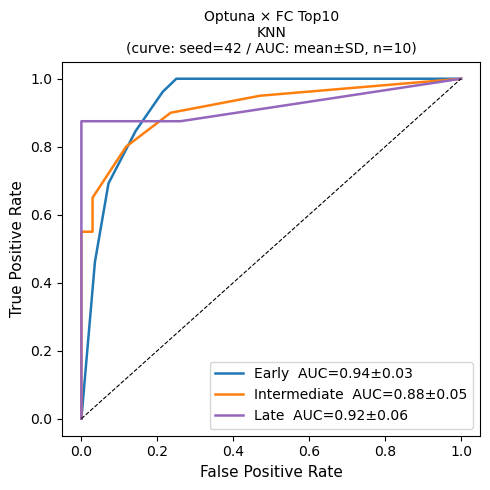

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5acc_cond1_KNN_roc.png


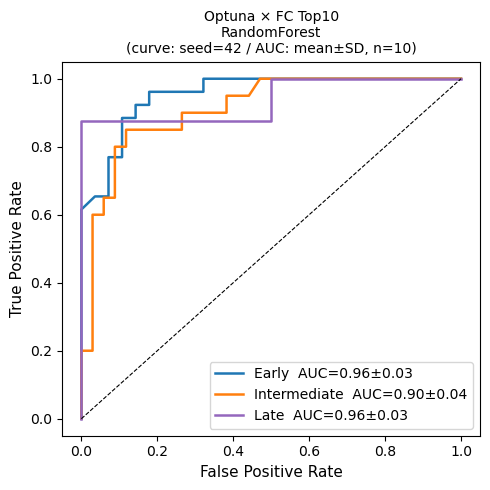

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5f1_cond1_RF_roc.png


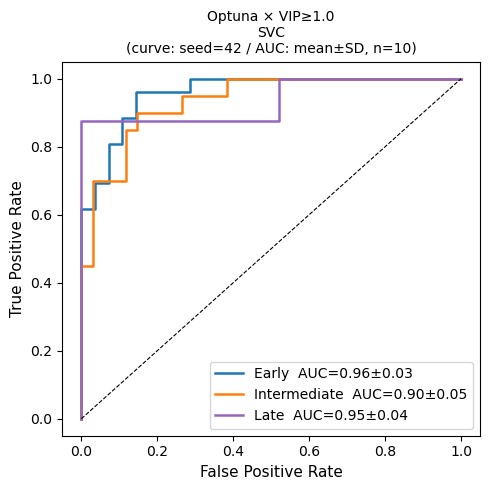

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5f1_cond2_SVC_roc.png


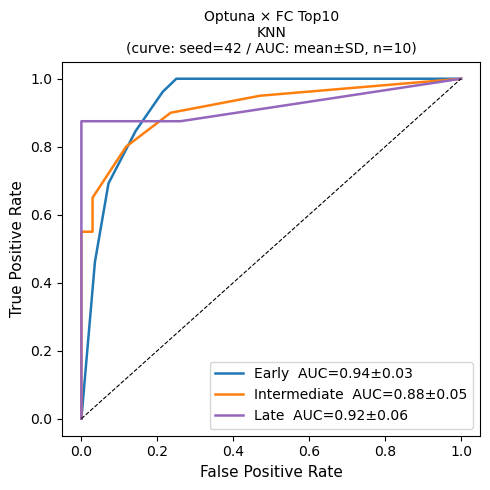

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5f1_cond1_KNN_roc.png


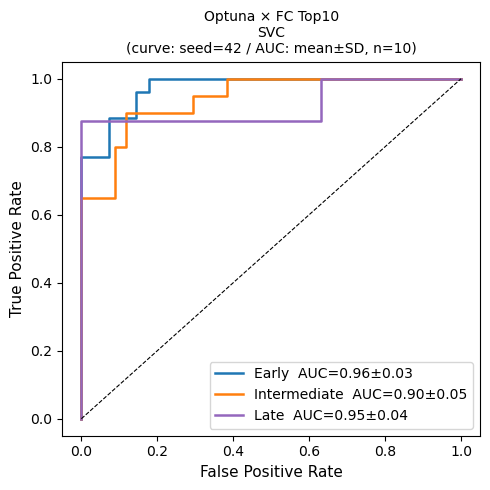

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5f1_cond1_SVC_roc.png


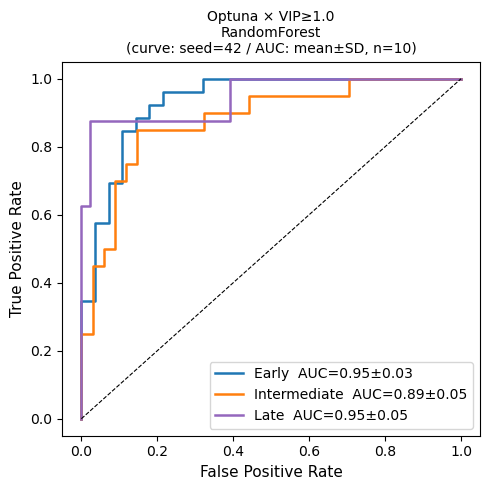

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/top5f1_cond2_RF_roc.png


In [8]:
line_colors = {0: C_EARLY, 2: C_INTER, 1: C_LATE}

def plot_roc_single(top5_df, metric_label, prefix):
    for _, row in top5_df.iterrows():
        cond = row['cond']
        mn   = row['model_name']
        sp   = COND_MAP[cond][0]

        # AUC per class: 10-seed mean ± std
        auc_per_class = {lbl: [] for lbl in LABEL_ORDER}
        for s in SEEDS:
            m_s     = results[cond][mn][s]['best_model']
            f_s     = results[cond][mn][s]['features']
            te_s    = sp[s]['test']
            X_s     = te_s[f_s].values
            y_s     = te_s['Label'].values
            y_prob_s     = m_s.predict_proba(X_s)
            model_cls_s  = list(m_s.classes_)
            y_bin_s      = label_binarize(y_s, classes=model_cls_s)
            for lbl in LABEL_ORDER:
                col = model_cls_s.index(lbl)
                try:
                    fpr, tpr, _ = roc_curve(y_bin_s[:, col], y_prob_s[:, col])
                    auc_per_class[lbl].append(auc(fpr, tpr))
                except Exception:
                    pass  # 해당 seed test에 클래스 없으면 skip

        # ROC curve 선: seed=42 기준
        model42     = results[cond][mn][LABEL_SEED]['best_model']
        feats42     = results[cond][mn][LABEL_SEED]['features']
        te42        = sp[LABEL_SEED]['test']
        X42         = te42[feats42].values
        y42         = te42['Label'].values
        y_prob42    = model42.predict_proba(X42)
        model_cls42 = list(model42.classes_)
        y_bin42     = label_binarize(y42, classes=model_cls42)

        fig, ax = plt.subplots(figsize=(5, 5))
        for lbl in LABEL_ORDER:
            col = model_cls42.index(lbl)
            fpr, tpr, _ = roc_curve(y_bin42[:, col], y_prob42[:, col])
            vals = auc_per_class[lbl]
            mean_auc = np.mean(vals) if vals else float('nan')
            std_auc  = np.std(vals)  if vals else float('nan')
            ax.plot(fpr, tpr, color=line_colors[lbl], lw=1.8,
                    label=f'{LABEL_NAMES[lbl]}  AUC={mean_auc:.2f}±{std_auc:.2f}')

        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title(
            f"{row['Condition']}\n{mn}\n"
            f"(curve: seed={LABEL_SEED} / AUC: mean±SD, n={len(SEEDS)})",
            fontsize=10
        )
        ax.legend(fontsize=10, loc='lower right')
        fig.tight_layout()

        fname = f"{prefix}_{cond}_{MODEL_SHORT[mn]}_roc.png"
        fig.savefig(f"{ROC_DIR}/{fname}", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {ROC_DIR}/{fname}")

plot_roc_single(top5_acc, 'Test Accuracy', 'top5acc')
plot_roc_single(top5_f1,  'Test F1-macro', 'top5f1')

In [9]:
def run_shap(model, X_train, X_test, features, fname, title, target_class=1):
    """Seed-42 beeswarm plot — target_class: 0=Early, 1=Late, 2=Intermediate."""
    short = [f.replace('g__', '') for f in features]
    X_tr  = pd.DataFrame(X_train, columns=short)
    X_te  = pd.DataFrame(X_test,  columns=short)

    inner = None
    if hasattr(model, 'named_steps'):
        inner = model.named_steps.get('svc') or model.named_steps.get('lr')
    base = inner if inner else model

    if isinstance(base, (RandomForestClassifier, XGBClassifier)):
        explainer = shap.TreeExplainer(base)
        shap_vals = explainer.shap_values(X_te)
    else:
        background = shap.sample(X_tr, 50, random_state=LABEL_SEED)
        explainer  = shap.KernelExplainer(model.predict_proba, background)
        shap_vals  = explainer.shap_values(X_te, nsamples=100)

    model_classes = list(model.classes_)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]

    col = model_classes.index(target_class)
    sv  = shap_vals[col]                      # (n_samples, n_feats)

    shap_exp = shap.Explanation(
        values          = sv,
        base_values     = np.zeros(len(X_te)),
        data            = X_te.values,
        feature_names   = short,
    )

    class_name = {0: 'Early', 1: 'Late', 2: 'Intermediate'}[target_class]
    fig, ax = plt.subplots(figsize=(8, max(4, 0.4 * len(short))))
    shap.plots.beeswarm(shap_exp, max_display=len(short),
                        show=False, plot_size=None)
    plt.title(f"{title}\nSHAP Beeswarm Plot – {class_name} class", fontsize=10)
    plt.tight_layout()
    save_path = f"{SHAP_DIR}/{fname}"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved (beeswarm): {save_path}")

Best: Optuna × FC Top10 / RandomForest  |  seeds: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
  seed-38 top: Iodobacter
  seed-39 top: Iodobacter
  seed-40 top: Iodobacter
  seed-41 top: Iodobacter
  seed-42 top: Iodobacter
  seed-43 top: Iodobacter
  seed-44 top: Iodobacter
  seed-45 top: Iodobacter
  seed-46 top: Iodobacter
  seed-47 top: Iodobacter
Union features: 12개 (각 seed FC Top10, union 기준)


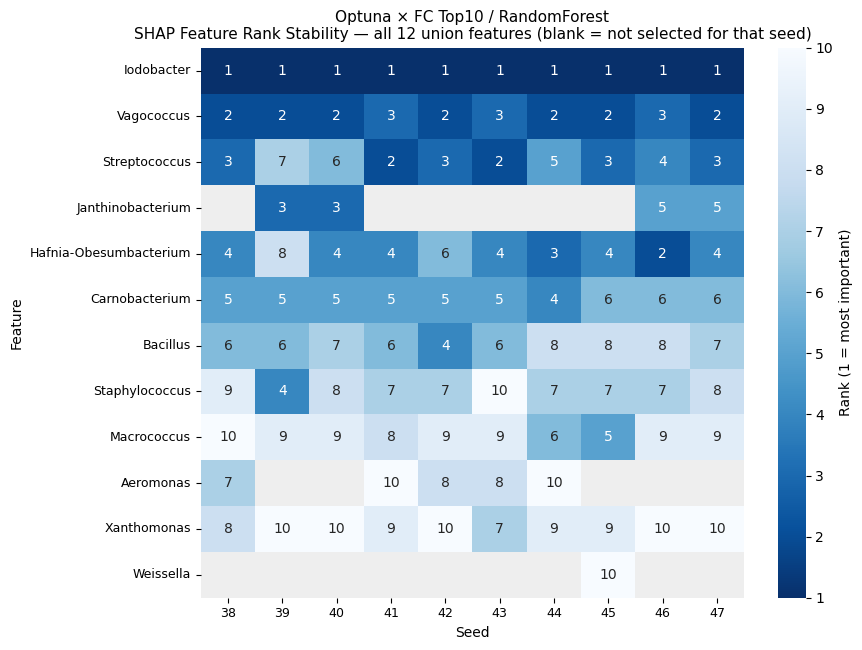

Saved (rank stability): /home/admin-01/taeho/BRL_chicken/revision/code/data/class_shap/cond1_RF_shap_rank_stability.png


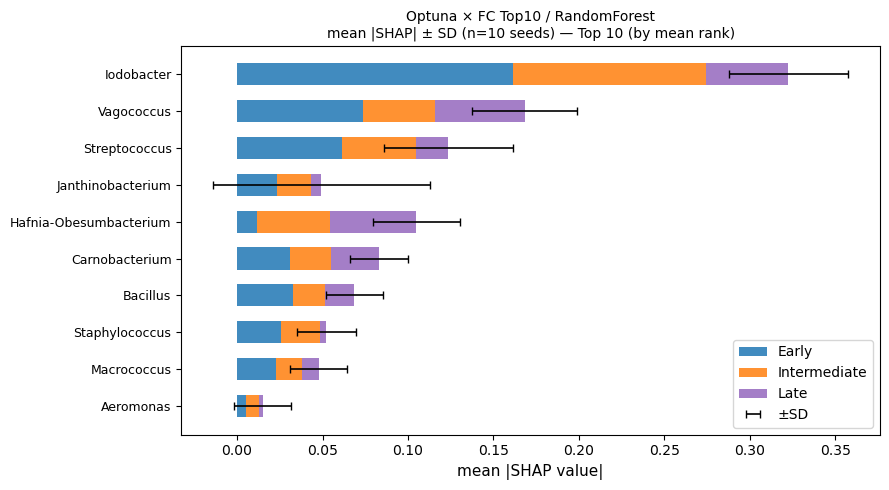

Saved (bar±SD):         /home/admin-01/taeho/BRL_chicken/revision/code/data/class_shap/cond1_RF_shap_seeds_bar.png


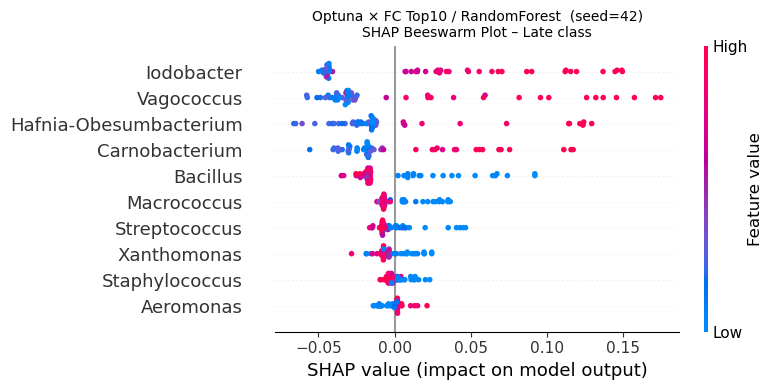

Saved (beeswarm): /home/admin-01/taeho/BRL_chicken/revision/code/data/class_shap/cond1_RF_shap.png

Best model: Optuna × FC Top10 / RandomForest


In [10]:
import shap

# ── Best model 추출 ──────────────────────────────────────────────
best_row = df_rank.nlargest(1, 'Test_F1_Mean').iloc[0]
bc  = best_row['cond']
bm  = best_row['model_name']
bms = MODEL_SHORT[bm]

all_splits = COND_MAP[bc][0]
seed_list  = sorted(results[bc][bm].keys())
print(f"Best: {COND_LABELS[bc]} / {bm}  |  seeds: {seed_list}")

# ── Seed별 SHAP importance 수집 ──────────────────────────────────
seed_importance = {}

for seed in seed_list:
    sp    = all_splits[seed]
    feats = results[bc][bm][seed]['features']
    model = results[bc][bm][seed]['best_model']
    short = [f.replace('g__', '') for f in feats]

    X_tr = pd.DataFrame(sp['train'][feats].values, columns=short)
    X_te = pd.DataFrame(sp['test'][feats].values,  columns=short)

    inner = None
    if hasattr(model, 'named_steps'):
        inner = model.named_steps.get('svc') or model.named_steps.get('lr')
    base = inner if inner else model

    if isinstance(base, (RandomForestClassifier, XGBClassifier)):
        explainer = shap.TreeExplainer(base)
        shap_vals = explainer.shap_values(X_te)
    else:
        background = shap.sample(X_tr, 50, random_state=seed)
        explainer  = shap.KernelExplainer(model.predict_proba, background)
        shap_vals  = explainer.shap_values(X_te, nsamples=100)

    model_classes = list(model.classes_)
    if isinstance(shap_vals, np.ndarray) and shap_vals.ndim == 3:
        shap_vals = [shap_vals[:, :, i] for i in range(shap_vals.shape[2])]

    by_class = {}
    total    = np.zeros(len(short))
    for lbl in LABEL_ORDER:
        col = model_classes.index(lbl)
        m   = np.mean(np.abs(shap_vals[col]), axis=0)
        by_class[lbl] = pd.Series(m, index=short)
        total += m

    seed_importance[seed] = {'total': pd.Series(total, index=short), 'by_class': by_class}
    print(f"  seed-{seed} top: {short[np.argmax(total)]}")

# ── Union feature set ─────────────────────────────────────────────
all_feats = sorted({f for s in seed_list for f in seed_importance[s]['total'].index})
print(f"Union features: {len(all_feats)}개 (각 seed FC Top10, union 기준)")

# ── Figure 1: Rank Stability Heatmap ─────────────────────────────
display_df = pd.DataFrame(index=all_feats, columns=seed_list, dtype=float)
for s in seed_list:
    imp_own  = seed_importance[s]['total']
    rank_own = imp_own.rank(ascending=False, method='min').astype(int)
    display_df[s] = rank_own.reindex(all_feats)   # 미선택 → NaN

display_df['_sort'] = display_df[seed_list].mean(axis=1)
display_df = display_df.sort_values('_sort').drop(columns='_sort')

annot_df = display_df.copy().astype(object)
for col in annot_df.columns:
    annot_df[col] = annot_df[col].apply(
        lambda x: '' if pd.isna(x) else str(int(x)))

n_feats = len(all_feats)
fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(seed_list)),
                                max(6, 0.55 * n_feats)))
sns.heatmap(display_df,
            annot=annot_df, fmt='', cmap='Blues_r',
            mask=display_df.isna(),
            vmin=1, vmax=10,
            ax=ax, cbar_kws={'label': 'Rank (1 = most important)'})
ax.set_facecolor('#eeeeee')
ax.set_title(f"{COND_LABELS[bc]} / {bm}\n"
             f"SHAP Feature Rank Stability — all {n_feats} union features "
             f"(blank = not selected for that seed)",
             fontsize=11)
ax.set_xlabel('Seed', fontsize=10)
ax.set_ylabel('Feature', fontsize=10)
ax.tick_params(labelsize=9)
plt.tight_layout()
rank_path = f"{SHAP_DIR}/{bc}_{bms}_shap_rank_stability.png"
plt.savefig(rank_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved (rank stability): {rank_path}")

# ── Figure 2: Stacked bar ± SD (mean rank 상위 10개) ─────────────
top10_feats = display_df.index.tolist()[:10]
top_n = len(top10_feats)

colors_map = {0: C_EARLY, 2: C_INTER, 1: C_LATE}
name_map   = {0: 'Early', 2: 'Intermediate', 1: 'Late'}

class_mat = {}
for lbl in LABEL_ORDER:
    rows = [seed_importance[s]['by_class'][lbl].reindex(top10_feats, fill_value=0.0).values
            for s in seed_list]
    class_mat[lbl] = np.array(rows)

total_mat = sum(class_mat[lbl] for lbl in LABEL_ORDER)
std_tot   = total_mat.std(axis=0)

y = np.arange(top_n)
fig, ax = plt.subplots(figsize=(9, max(5, 0.45 * top_n)))
lefts = np.zeros(top_n)
for lbl in LABEL_ORDER:
    vals = class_mat[lbl].mean(axis=0)
    ax.barh(y, vals, left=lefts, height=0.6,
            color=colors_map[lbl], label=name_map[lbl], alpha=0.85)
    lefts += vals
ax.errorbar(lefts, y, xerr=std_tot, fmt='none',
            color='black', capsize=3, linewidth=1.2, label='±SD')
ax.set_yticks(y)
ax.set_yticklabels(top10_feats, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mean |SHAP value|', fontsize=11)
ax.set_title(f"{COND_LABELS[bc]} / {bm}\n"
             f"mean |SHAP| ± SD (n={len(seed_list)} seeds) — Top {top_n} (by mean rank)",
             fontsize=10)
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
bar_path = f"{SHAP_DIR}/{bc}_{bms}_shap_seeds_bar.png"
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved (bar±SD):         {bar_path}")

# ── Figure 3: seed-42 beeswarm (논문용 원본 유지) ────────────────
sp42    = all_splits[LABEL_SEED]
feats42 = results[bc][bm][LABEL_SEED]['features']
model42 = results[bc][bm][LABEL_SEED]['best_model']
run_shap(model42,
         sp42['train'][feats42].values,
         sp42['test'][feats42].values,
         feats42,
         fname  = f"{bc}_{bms}_shap.png",
         title  = f"{COND_LABELS[bc]} / {bm}  (seed={LABEL_SEED})")

print(f"\nBest model: {COND_LABELS[bc]} / {bm}")

## 9. Save

| File | Contents |
|---|---|
| `classification_results.pkl` | Full results dictionary (4 conditions × 10 seeds × 5 models) |
| `best_models.pkl` | Top-5 by Accuracy / Top-5 by F1 — summary DataFrames |
| `best_model_pipeline.pkl` | Best model pipeline from seed-42 (used in `validation.ipynb`) |
| `classification_performance.xlsx` | Performance summary table (mean ± SD) |
| `sensitivity_results.pkl` | F1 results for 10 label seeds × 10 train seeds (saved in Section 13) |

Supplementary figures → `data/class_confusion/`, `data/class_roc/` (saved in Section 12)

In [11]:
from openpyxl.styles import PatternFill

# ── PKL ──────────────────────────────────────────────────────
with open(f"{PKL_DIR}/classification_results.pkl", 'wb') as f:
    pickle.dump(results, f)
with open(f"{PKL_DIR}/best_models.pkl", 'wb') as f:
    pickle.dump({'top5_acc': top5_acc, 'top5_f1': top5_f1}, f)
print("PKL saved →", PKL_DIR)

# ── Excel ─────────────────────────────────────────────────────
MODEL_ORDER = ['RandomForest', 'XGBoost', 'SVC', 'LogisticRegression', 'KNN']

rows = []
for cond in COND_MAP:
    for model_name in MODEL_ORDER:
        if model_name not in model_configs:
            continue
        taccs = [results[cond][model_name][s]['train_acc'] for s in SEEDS]
        accs  = [results[cond][model_name][s]['test_acc']  for s in SEEDS]
        tf1s  = [results[cond][model_name][s]['train_f1']  for s in SEEDS]
        f1s   = [results[cond][model_name][s]['test_f1']   for s in SEEDS]
        bp42  = results[cond][model_name][LABEL_SEED]['best_params']

        def fmt(m, s): return f"{m:.4f} ± {s:.4f}"

        rows.append({
            'Condition':          COND_LABELS[cond],
            'Model':              model_name,
            'Train Accuracy':     fmt(np.mean(taccs), np.std(taccs)),
            'Test Accuracy':      fmt(np.mean(accs),  np.std(accs)),
            'Train F1 Macro':     fmt(np.mean(tf1s),  np.std(tf1s)),
            'Test F1 Macro':      fmt(np.mean(f1s),   np.std(f1s)),
            '_test_f1_mean':      np.mean(f1s),   # 정렬/하이라이트용, 나중에 제거
            'Best_Params_seed42': str(bp42),
        })

df_perf = pd.DataFrame(rows)

yellow_fill = PatternFill(start_color='FFFF00', end_color='FFFF00', fill_type='solid')
best_idx = set(df_perf.groupby('Condition')['_test_f1_mean'].idxmax().values)

df_export = df_perf.drop(columns=['_test_f1_mean'])
xlsx_path  = f"{DATA_DIR}/classification_performance.xlsx"

with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='All_Results', index=False)
    top5_acc[['Condition','Model','Test_Acc_Mean','Test_Acc_Std',
              'Test_F1_Mean','Test_F1_Std']].to_excel(
        writer, sheet_name='Top5_by_Accuracy', index=False)
    top5_f1[['Condition','Model','Test_Acc_Mean','Test_Acc_Std',
             'Test_F1_Mean','Test_F1_Std']].to_excel(
        writer, sheet_name='Top5_by_F1', index=False)

    ws = writer.sheets['All_Results']
    n_cols = df_export.shape[1]
    for df_row_idx in best_idx:
        for col in range(1, n_cols + 1):
            ws.cell(row=df_row_idx + 2, column=col).fill = yellow_fill

print(f"Excel saved → {xlsx_path}")
print()
print("=== Top 5 by Accuracy ===")
print(top5_acc[['Condition','Model','Test_Acc_Mean','Test_F1_Mean']].to_string(index=False))
print()
print("=== Top 5 by F1 ===")
print(top5_f1[['Condition','Model','Test_Acc_Mean','Test_F1_Mean']].to_string(index=False))

PKL saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl
Excel saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/classification_performance.xlsx

=== Top 5 by Accuracy ===
        Condition        Model  Test_Acc_Mean  Test_F1_Mean
Optuna × FC Top10 RandomForest       0.857407      0.847586
 Optuna × VIP≥1.0          SVC       0.855556      0.845958
 Optuna × VIP≥1.0 RandomForest       0.850000      0.833308
Optuna × FC Top10          SVC       0.846296      0.836235
Optuna × FC Top10          KNN       0.844444      0.839415

=== Top 5 by F1 ===
        Condition        Model  Test_Acc_Mean  Test_F1_Mean
Optuna × FC Top10 RandomForest       0.857407      0.847586
 Optuna × VIP≥1.0          SVC       0.855556      0.845958
Optuna × FC Top10          KNN       0.844444      0.839415
Optuna × FC Top10          SVC       0.846296      0.836235
 Optuna × VIP≥1.0 RandomForest       0.850000      0.833308


## 10. save pipeline 

In [12]:
# ── Best model pipeline 저장 ─────────────────────────────────────
# feats/model은 SHAP 루프에서 마지막 seed 값으로 덮어씌워지므로
# results에서 LABEL_SEED를 명시적으로 꺼내서 저장
_feats42 = results[bc][bm][LABEL_SEED]['features']
_model42  = results[bc][bm][LABEL_SEED]['best_model']

pipeline_info = {
    'condition':   bc,
    'cond_label':  COND_LABELS[bc],
    'model_name':  bm,
    'seed':        LABEL_SEED,
    'features':    _feats42,
    'model':       _model42,
    'label_order': LABEL_ORDER,
    'label_names': LABEL_NAMES,
    'splits_pkl':  'labeled_splits.pkl' if bc in ['cond1', 'cond2'] else 'kmeans_labeled_splits.pkl',
}
with open(f"{PKL_DIR}/best_model_pipeline.pkl", 'wb') as f:
    pickle.dump(pipeline_info, f)
print(f"Saved → {PKL_DIR}/best_model_pipeline.pkl")
print(f"  Condition : {pipeline_info['cond_label']}")
print(f"  Model     : {bm}  (seed={LABEL_SEED})")
print(f"  Features  : {_feats42}")

Saved → /home/admin-01/taeho/BRL_chicken/revision/code/data/pkl/best_model_pipeline.pkl
  Condition : Optuna × FC Top10
  Model     : RandomForest  (seed=42)
  Features  : ['g__Iodobacter', 'g__Carnobacterium', 'g__Vagococcus', 'g__Hafnia-Obesumbacterium', 'g__Bacillus', 'g__Macrococcus', 'g__Streptococcus', 'g__Xanthomonas', 'g__Staphylococcus', 'g__Aeromonas']


## 11. Figure — Best Model per Condition (Main Paper)

One algorithm selected per condition (Cond 1–4) based on highest test F1 score.
Confusion matrix and ROC curve for each are saved as separate figures using the seed-42 test set.

> Per-seed figures across all 10 seeds are generated in Section 12 (Supplementary).

=== Condition별 Best Model (Test Acc 기준) ===
         Condition        Model  Test_Acc_Mean  Test_Acc_Std  Test_F1_Mean  Test_F1_Std
 Optuna × FC Top10 RandomForest       0.857407      0.027530      0.847586     0.041914
  Optuna × VIP≥1.0          SVC       0.855556      0.055432      0.845958     0.060035
K-means × FC Top10 RandomForest       0.753704      0.051086      0.726324     0.044430
 K-means × VIP≥1.0          SVC       0.787037      0.055710      0.757877     0.050743


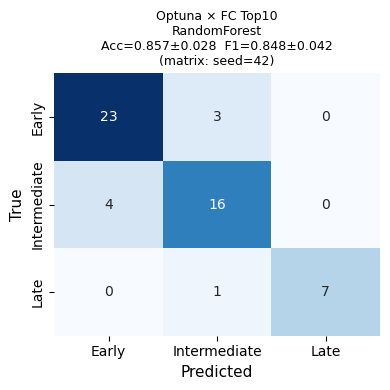

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/fig_cond_best_cond1_RF_confusion.png


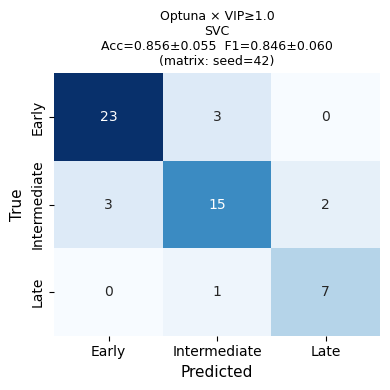

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/fig_cond_best_cond2_SVC_confusion.png


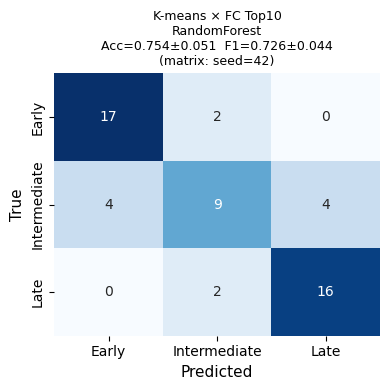

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/fig_cond_best_cond3_RF_confusion.png


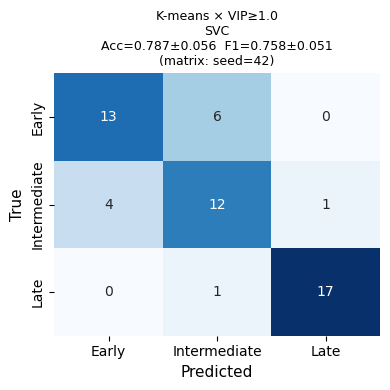

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/fig_cond_best_cond4_SVC_confusion.png


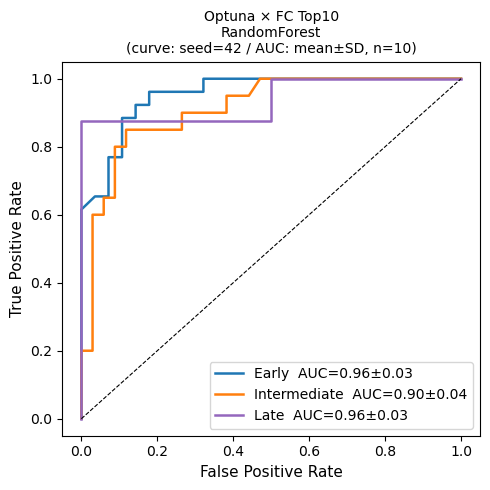

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/fig_cond_best_cond1_RF_roc.png


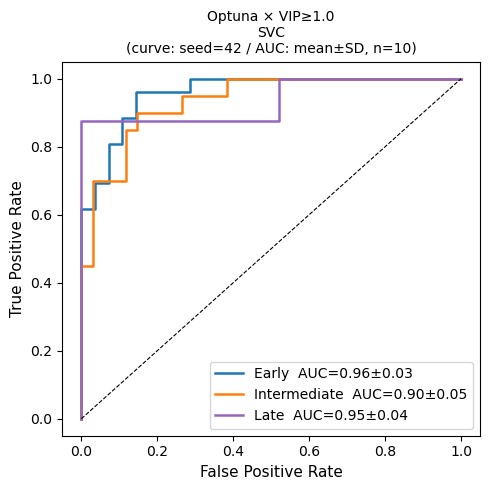

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/fig_cond_best_cond2_SVC_roc.png


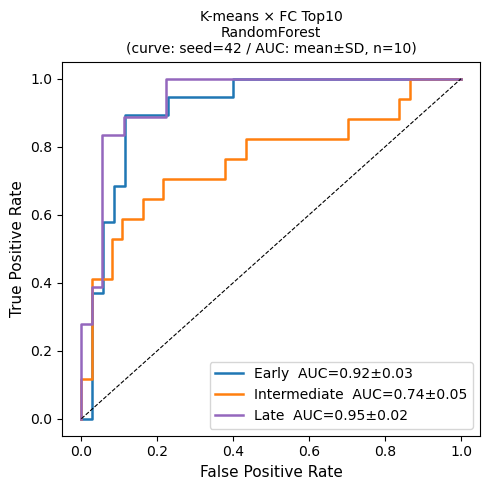

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/fig_cond_best_cond3_RF_roc.png


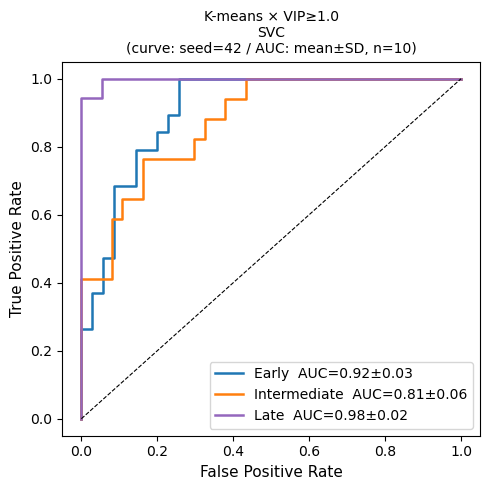

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/fig_cond_best_cond4_SVC_roc.png


In [13]:
# ── Condition별 Test Acc 기준 best model 1개씩 ────────────────────
best_rows = []
for cond in ['cond1', 'cond2', 'cond3', 'cond4']:
    cond_df = df_rank[df_rank['cond'] == cond]
    best_rows.append(cond_df.nlargest(1, 'Test_Acc_Mean').iloc[0])

fig_best_df = pd.DataFrame(best_rows).reset_index(drop=True)

print("=== Condition별 Best Model (Test Acc 기준) ===")
print(fig_best_df[['Condition', 'Model',
                    'Test_Acc_Mean', 'Test_Acc_Std',
                    'Test_F1_Mean',  'Test_F1_Std']].to_string(index=False))

# ── Confusion Matrix ──────────────────────────────────────────────
plot_confusion_single(fig_best_df, 'Test_Acc', 'fig_cond_best')

# ── ROC Curve ─────────────────────────────────────────────────────
plot_roc_single(fig_best_df, 'Test_Acc', 'fig_cond_best')

## 12. Supplementary — Per-seed Confusion Matrix + ROC (Best Model)

Based on the best model: Optuna × FC Top10 / Random Forest.
Figures generated from each seed's individual test set across all 10 seeds.

| Item | Description |
|---|---|
| Target | Cond 1 × Random Forest |
| Iterations | Seeds 38–47, one figure per seed |
| Output | `data/class_confusion/suppl_seed{seed}_confusion.png` |
| Output | `data/class_roc/suppl_seed{seed}_roc.png` |

In [14]:
SUPPL_COND  = 'cond1'
SUPPL_MODEL = 'RandomForest'
suppl_splits = COND_MAP[SUPPL_COND][0]

for seed in SEEDS:
    model = results[SUPPL_COND][SUPPL_MODEL][seed]['best_model']
    feats = results[SUPPL_COND][SUPPL_MODEL][seed]['features']
    te    = suppl_splits[seed]['test']
    X_te  = te[feats].values
    y_te  = te['Label'].values
    y_pr  = model.predict(X_te)

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(y_te, y_pr, labels=LABEL_ORDER)
    acc = accuracy_score(y_te, y_pr)
    f1  = f1_score(y_te, y_pr, average='macro')

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=[LABEL_NAMES[l] for l in LABEL_ORDER],
                yticklabels=[LABEL_NAMES[l] for l in LABEL_ORDER])
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(
        f"Supplementary — seed={seed}\n"
        f"{COND_LABELS[SUPPL_COND]} / {SUPPL_MODEL}\n"
        f"Acc={acc:.3f}  F1={f1:.3f}",
        fontsize=9
    )
    fig.tight_layout()
    fname = f"{CONF_DIR}/suppl_seed{seed}_confusion.png"
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

    # ── ROC Curve ─────────────────────────────────────────────
    y_prob      = model.predict_proba(X_te)
    model_cls   = list(model.classes_)
    y_bin       = label_binarize(y_te, classes=model_cls)

    fig, ax = plt.subplots(figsize=(5, 5))
    for lbl in LABEL_ORDER:
        col = model_cls.index(lbl)
        fpr, tpr, _ = roc_curve(y_bin[:, col], y_prob[:, col])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color={0: C_EARLY, 2: C_INTER, 1: C_LATE}[lbl],
                lw=1.8, label=f'{LABEL_NAMES[lbl]}  AUC={roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(
        f"Supplementary — seed={seed}\n"
        f"{COND_LABELS[SUPPL_COND]} / {SUPPL_MODEL}",
        fontsize=10
    )
    ax.legend(fontsize=10, loc='lower right')
    fig.tight_layout()
    fname = f"{ROC_DIR}/suppl_seed{seed}_roc.png"
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {fname}")

print("\nSupplementary figures 저장 완료.")

Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/suppl_seed38_confusion.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/suppl_seed38_roc.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/suppl_seed39_confusion.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/suppl_seed39_roc.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/suppl_seed40_confusion.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/suppl_seed40_roc.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/suppl_seed41_confusion.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/suppl_seed41_roc.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_confusion/suppl_seed42_confusion.png
Saved: /home/admin-01/taeho/BRL_chicken/revision/code/data/class_roc/suppl_seed42_roc.png
Saved: /home/admin-01/taeho/BRL_chicken/

## 13. Sensitivity Analysis — 5 Models × 10 label seeds × 10 train seeds

**Objective**: Simultaneously quantify the effects of model choice, labeling threshold (label seed), and data partitioning (train seed) on classification performance.

| Item | Description |
|---|---|
| Condition | Cond 1 (Optuna × FC Top10) |
| Label seed | 38–47 — independent Optuna threshold fit per seed |
| Train seed | 38–47 — same base splits with seed-specific labels applied |
| Models | RF, XGBoost, SVC, Logistic Regression, KNN — all 5 |
| Metrics | Test F1-macro, test Accuracy |
| Visualization | Per-model boxplot (x = model, each box = 100 combinations); seed-42 marked separately |
| Output | `sensitivity_results.pkl`, `fig_sensitivity_model.png` |

**Summary of results**

| label_seed | F1 mean | F1 std | Acc mean | Acc std |
|---|---|---|---|---|
| 38 | 0.860 | 0.048 | 0.872 | 0.038 |
| 39 | 0.794 | 0.055 | 0.824 | 0.038 |
| 40 | 0.848 | 0.040 | 0.861 | 0.030 |
| 41 | 0.851 | 0.039 | 0.861 | 0.031 |
| **42** | **0.848** | **0.042** | **0.857** | **0.028** |
| 43 | 0.860 | 0.048 | 0.872 | 0.038 |
| 44 | 0.790 | 0.036 | 0.822 | 0.022 |
| 45 | 0.851 | 0.039 | 0.861 | 0.031 |
| 46 | 0.819 | 0.050 | 0.843 | 0.040 |
| 47 | 0.833 | 0.051 | 0.856 | 0.041 |
| **All 100 combinations** | **0.835** | **0.052** | **0.853** | **0.038** |

**Interpretation**

- F1 mean range across label seeds: 0.790–0.860 (span: 0.070)
- Seed-42 F1 (0.848) ≥ overall mean (0.835); seed-42 Acc std (0.028) is the lowest across all seeds → most stable
- Between-seed variability in mean F1 (std ≈ 0.025) is smaller than within-seed variability (std ≈ 0.040–0.055) → train seed selection contributes more to performance variance than label seed selection
- Seeds 39 and 44 show relatively low F1 (≈ 0.79), likely reflecting threshold placement near class boundaries
- Overall: seed-42 ranks in the top tier for performance and achieves the lowest std → appropriate as the representative seed